In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/train.csv')

In [3]:
df_clean = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')

In [4]:
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(df_clean['Arrival Delay in Minutes'].median())

In [5]:
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

In [6]:
service_performance = df_clean[service_cols].mean().sort_values(ascending=False)
print("Average Service Scores:\n", service_performance)

Average Service Scores:
 Inflight service                     3.640428
Baggage handling                     3.631833
Seat comfort                         3.439396
On-board service                     3.382363
Inflight entertainment               3.358158
Leg room service                     3.351055
Checkin service                      3.304290
Cleanliness                          3.286351
Online boarding                      3.250375
Food and drink                       3.202129
Departure/Arrival time convenient    3.060296
Gate location                        2.976883
Ease of Online booking               2.756901
Inflight wifi service                2.729683
dtype: float64


In [7]:
group_comparison = df_clean.groupby('satisfaction')[service_cols].mean().T
print("\nGroup Comparison (Satisfied vs Dissatisfied):\n", group_comparison)


Group Comparison (Satisfied vs Dissatisfied):
 satisfaction                       neutral or dissatisfied  satisfied
Inflight wifi service                             2.399633   3.161288
Departure/Arrival time convenient                 3.129112   2.970305
Ease of Online booking                            2.546850   3.031582
Gate location                                     2.976121   2.977879
Food and drink                                    2.958050   3.521310
Online boarding                                   2.656125   4.027474
Seat comfort                                      3.036295   3.966530
Inflight entertainment                            2.894156   3.964931
On-board service                                  3.019158   3.857324
Leg room service                                  2.990812   3.822143
Baggage handling                                  3.375991   3.966396
Checkin service                                   3.042952   3.646041
Inflight service                          

In [8]:
df_clean['sat_binary'] = df_clean['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

In [9]:
correlations = df_clean[service_cols + ['sat_binary']].corr()['sat_binary'].sort_values(ascending=False).drop('sat_binary')
print("\nTop 5 Drivers of Satisfaction:\n", correlations.head(5))


Top 5 Drivers of Satisfaction:
 Online boarding           0.503557
Inflight entertainment    0.398059
Seat comfort              0.349459
On-board service          0.322383
Leg room service          0.313131
Name: sat_binary, dtype: float64


C:\Users\Testing\AppData\Local\Temp\ipykernel_10340\4126504214.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


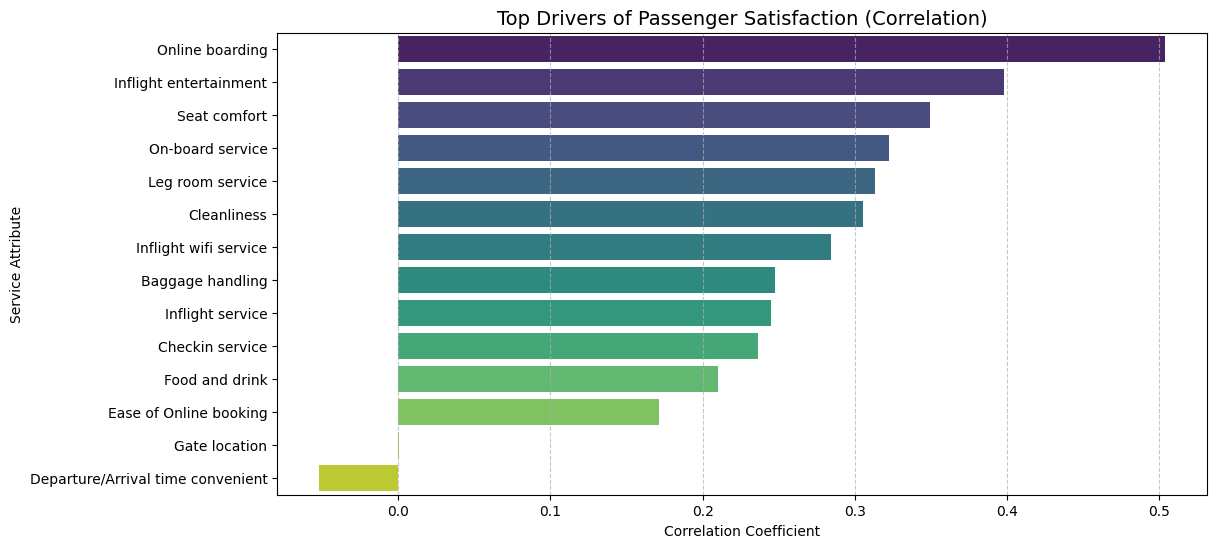

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Top Drivers of Passenger Satisfaction (Correlation)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Service Attribute')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [11]:
df_clean.to_csv('cleaned_airline_satisfaction.csv', index=False)

In [12]:
comparison = df_clean.groupby('satisfaction')[service_cols].mean().T
df_clean['sat_binary'] = df_clean['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})
correlations = df_clean[service_cols + ['sat_binary']].corr()['sat_binary'].sort_values(ascending=False).drop('sat_binary')

In [13]:
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Text(0.5, 0, 'Average Score (0-5)')

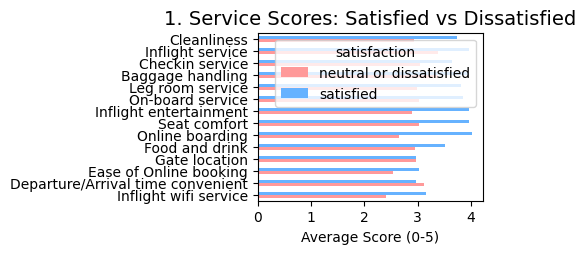

In [14]:
plt.subplot(2, 2, 1)
comparison.plot(kind='barh', ax=plt.gca(), color=['#FF9999', '#66B2FF'])
plt.title('1. Service Scores: Satisfied vs Dissatisfied', fontsize=14)
plt.xlabel('Average Score (0-5)')

C:\Users\Testing\AppData\Local\Temp\ipykernel_10340\4289809989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


Text(0.5, 0, 'Correlation Strength')

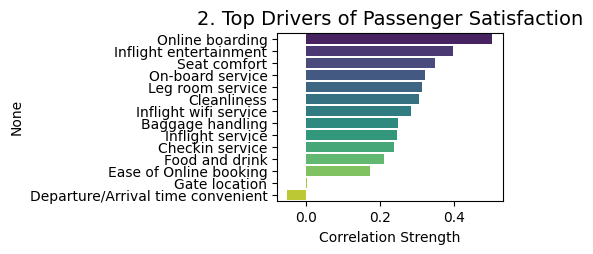

In [15]:
plt.subplot(2, 2, 2)
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('2. Top Drivers of Passenger Satisfaction', fontsize=14)
plt.xlabel('Correlation Strength')

Text(0.5, 1.0, '3. Satisfaction Levels by Travel Class')

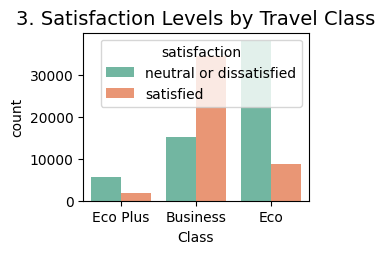

In [16]:
plt.subplot(2, 2, 3)
sns.countplot(data=df_clean, x='Class', hue='satisfaction', palette='Set2')
plt.title('3. Satisfaction Levels by Travel Class', fontsize=14)

Text(0.5, 1.0, '4. Service Attribute Correlation Heatmap')

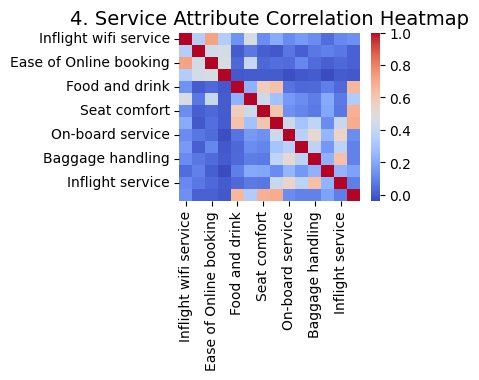

In [17]:
plt.subplot(2, 2, 4)
sns.heatmap(df_clean[service_cols].corr(), cmap='coolwarm', annot=False)
plt.title('4. Service Attribute Correlation Heatmap', fontsize=14)

In [18]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>